## ML&Fintech HW3 Ch12 Q10

Name: Alvin B. Lin\
Student ID: 112652040\
HW Number: 3\
Date: 13/10/2025

#### 10.  In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.

(a) Generate a simulated data set with 20 observations in each of
three classes (i.e. 60 observations total), and 50 variables.

*Hint: There are a number of functions in Python that you can
use to generate data. One example is the* `normal()` *method of
the* `random()` *function in* `numpy` *; the* `uniform()` *method is another
option. Be sure to add a mean shift to the observations in each
class so that there are three distinct classes.*


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# (a) Generate a simulated data set with 20 observations in each of
# three classes (i.e. 60 observations total), and 50 variables.
np.random.seed(0)
n_classes = 3   # Number of classes
n_per_class = 20  # Observations per class
n_features = 50  # Number of features
data = []
labels = []
for i in range(n_classes):
    mean_shift = i * 5  # Mean shift for each class
    class_data = np.random.normal(loc=mean_shift, scale=1.0, size=(n_per_class, n_features))
    data.append(class_data)
    labels += [i] * n_per_class

data = np.vstack(data)
labels = np.array(labels)
df = pd.DataFrame(data)
df['Class'] = labels
print(df.head())

          0         1         2         3         4         5         6  \
0  1.764052  0.400157  0.978738  2.240893  1.867558 -0.977278  0.950088   
1 -0.895467  0.386902 -0.510805 -1.180632 -0.028182  0.428332  0.066517   
2  1.883151 -1.347759 -1.270485  0.969397 -1.173123  1.943621 -0.413619   
3 -0.068242  1.713343 -0.744755 -0.826439 -0.098453 -0.663478  1.126636   
4 -0.369182 -0.239379  1.099660  0.655264  0.640132 -1.616956 -0.024326   

          7         8         9  ...        41        42        43        44  \
0 -0.151357 -0.103219  0.410599  ... -1.420018 -1.706270  1.950775 -0.509652   
1  0.302472 -0.634322 -0.362741  ...  1.222445  0.208275  0.976639  0.356366   
2 -0.747455  1.922942  1.480515  ...  0.439392  0.166673  0.635031  2.383145   
3 -1.079932 -1.147469 -0.437820  ...  0.267051 -0.039283 -1.168093  0.523277   
4 -0.738031  0.279925 -0.098150  ... -0.397272 -0.132881 -0.297791 -0.309013   

         45        46        47        48        49  Class  
0 -0.43

---

(b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

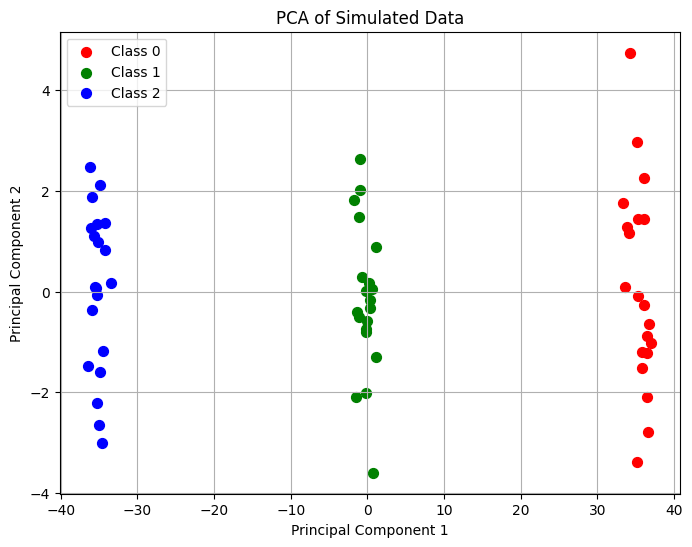

In [ ]:
# (b) Perform PCA on the data set and plot the first two principal components,
# coloring the points according to their true class labels.
# Standardize the data
features = df.columns[:-1]  # Exclude the class label column
x = df.loc[:, features].values
# Perform PCA
x_standardized = StandardScaler().fit_transform(x)
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)

principalDf = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])
principalDf['Class'] = df['Class'].values
# Plot the PCA results
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']
for class_value in range(n_classes):
    indicesToKeep = principalDf['Class'] == class_value
    plt.scatter(principalDf.loc[indicesToKeep, 'PC1'],
                principalDf.loc[indicesToKeep, 'PC2'],
                c=colors[class_value],
                s=50)
    
plt.title('PCA of Simulated Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(['Class 0', 'Class 1', 'Class 2'])
plt.grid()
plt.show()


Three classes are separated, hence the process continues.

---

(c) Perform K-means clustering of the observations with K = 3. How well do the clusters that you obtained in K-means clustering compare to the true class labels?

*Hint: You can use the* `pd.crosstab()` *function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.*

In [ ]:
# (c) K-means Clustering with K=3
kmeans_3_raw = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_3_raw = kmeans_3_raw.fit_predict(x)

# Compare to true labels using crosstab
print("(c) K-means Clustering (K=3) on Raw Data:")
cross_tab_3_raw = pd.crosstab(df['Class'], clusters_3_raw,
                              rownames=['True Class'], colnames=['Cluster Label'])
print(cross_tab_3_raw)

(c) K-means Clustering (K=3) on Standardized Raw Data:
Cluster Label   0   1   2
True Class               
0               0   0  20
1              20   0   0
2               0  20   0


The effect of clustering is extremely good, all the clusters have no overlapping class members.

---

(d) Perform K-means clustering with K = 2. Describe your results.

In [25]:
# (d) K-means Clustering with K=2 on Raw Data
kmeans_2_raw = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters_2_raw = kmeans_2_raw.fit_predict(x)

# Compare to true labels using crosstab
print("\n(d) K-means Clustering (K=2) on Raw Data:")
cross_tab_2_raw = pd.crosstab(df['Class'], clusters_2_raw,
                              rownames=['True Class'], colnames=['Cluster Label'])
print(cross_tab_2_raw)


(d) K-means Clustering (K=2) on Raw Data:
Cluster Label   0   1
True Class           
0              20   0
1              20   0
2               0  20


The result of putting all the data into 2 clusters show that 2 classes, got from (b) merge to a single cluster, while the other class remains in a cluster.

---

(e) Now perform K-means clustering with K = 4, and describe your results.

In [26]:
# (e) K-means Clustering with K=4 on Raw Data
kmeans_4_raw = KMeans(n_clusters=4, random_state=42, n_init='auto')
clusters_4_raw = kmeans_4_raw.fit_predict(x)

# Compare to true labels using crosstab
print("\n(e) K-means Clustering (K=4) on Raw Data:")
cross_tab_4_raw = pd.crosstab(df['Class'], clusters_4_raw,
                              rownames=['True Class'], colnames=['Cluster Label'])
print(cross_tab_4_raw)


(e) K-means Clustering (K=4) on Raw Data:
Cluster Label   0   1   2  3
True Class                  
0               0   0  20  0
1              11   0   0  9
2               0  20   0  0


We see that since we have only 3 classes, but have 4 clusters, we must have at least one class being separated into multiple clusters, here we see class 1 has now 11 members in cluster 0 and 9 members in cluster 3.

---

(f) Now perform K-means clustering with K = 3 on the first two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the 60 × 2 matrix of which the first column is the first principal component score vector, and the second column is the second principal componen score vector. Comment on the results.

In [27]:
# (f) K-means Clustering with K=3 on the first two Principal Component Scores
pca_data = principalDf[['PC1', 'PC2']].values

kmeans_3_pca = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters_3_pca = kmeans_3_pca.fit_predict(pca_data)

# Compare to true labels using crosstab
print("\n(f) K-means Clustering (K=3) on First Two Principal Components (PC1, PC2):")
cross_tab_3_pca = pd.crosstab(df['Class'], clusters_3_pca,
                              rownames=['True Class'], colnames=['Cluster Label'])
print(cross_tab_3_pca)


(f) K-means Clustering (K=3) on First Two Principal Components (PC1, PC2):
Cluster Label   0   1   2
True Class               
0               0   0  20
1              20   0   0
2               0  20   0


The result is exactly the same as the one got from (c), this may be caused by the fact that PCA1 and PCA2 are the major components (for clustering).

---

(g) Using the `StandardScaler()` estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

In [28]:
# (g) Using the `StandardScaler()` estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df.iloc[:, :-1].values)
kmeans_scaled = KMeans(n_clusters=n_classes, random_state=0)
kmeans_scaled.fit(x_scaled)
cluster_labels_scaled = kmeans_scaled.labels_
confusion_matrix_scaled = pd.crosstab(df['Class'], cluster_labels_scaled,
                                        rownames=['True Class'], colnames=['Cluster Label (Scaled K=3)'])
print(confusion_matrix_scaled)

Cluster Label (Scaled K=3)   0   1   2
True Class                            
0                            0   0  20
1                           20   0   0
2                            0  20   0


**Why It Doesn't Matter Here?** In this specific simulated dataset, the raw data was generated such that **all 50 variables have the same scale** (standard deviation of 1.0) and the same structure of mean shifts. When all variables share the same initial scale, standardization has very little effect on the relative distances between observations, so the clustering outcome remains unchanged.